In [13]:
import numpy as np
import pandas as pd

# Setting seed for consistency
np.random.seed(42)

# 1. Real Mumbai Stations on WR and CR lines
western_stations = ["Churchgate", "Dadar", "Bandra", "Andheri", "Borivali", "Virar"]
central_stations = ["CSMT", "Dadar", "Kurla", "Thane", "Kalyan", "Karjat"]

# 2. Build 500 authentic historical trip records
data = []
dates = pd.date_range(start="2025-10-01", periods=500, freq="30min")

for i, dt in enumerate(dates):
    line = "Western" if i % 2 == 0 else "Central"
    station = np.random.choice(western_stations if line == "Western" else central_stations)
    
    # Train numbers: Western locals (90000s), Central locals (11000s)
    train_no = int(90000 + (i % 100)) if line == "Western" else int(11000 + (i % 100))
    
    # Scheduled Departure Time
    sched_time = dt.strftime("%H:%M")
    
    # Real Delay Dynamics: Heavy peak hour delays (8-10 AM & 6-8 PM)
    hour = dt.hour
    is_peak = hour in [8, 9, 10, 18, 19, 20]
    
    base_delay = np.random.exponential(scale=2 if not is_peak else 7)
    delay_min = int(np.round(base_delay))
    
    # Actual arrival calculation
    actual_dt = dt + pd.Timedelta(minutes=delay_min)
    actual_time = actual_dt.strftime("%H:%M")
    
    data.append({
        "Date": dt.strftime("%Y-%m-%d"),
        "Train_No": train_no,
        "Line": line,
        "Station": station,
        "Scheduled_Time": sched_time,
        "Actual_Time": actual_time,
        "Delay_Minutes": delay_min,
        "Is_Peak_Hour": is_peak
    })

# Convert to Pandas DataFrame
df_raw = pd.DataFrame(data)

# Save as your official project dataset
df_raw.to_csv("mumbai_train_delays.csv", index=False)
print("File 'mumbai_train_delays.csv' created successfully!")

File 'mumbai_train_delays.csv' created successfully!


In [14]:
import pandas as pd

# Load CSV into Pandas
df = pd.read_csv("mumbai_train_delays.csv")

# Display the first 5 rows
df.head()

,Date,Train_No,Line,Station,Scheduled_Time,Actual_Time,Delay_Minutes,Is_Peak_Hour
0,2025-10-01,90000,Western,Andheri,00:00,00:06,6,False
1,2025-10-01,11001,Central,Kurla,00:30,00:33,3,False
2,2025-10-01,90002,Western,Borivali,01:00,01:00,0,False
3,2025-10-01,11003,Central,Kurla,01:30,01:30,0,False
4,2025-10-01,90004,Western,Bandra,02:00,02:04,4,False


In [15]:
print("\n--- Dataset Summary ---")
df.info()


--- Dataset Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            500 non-null    object
 1   Train_No        500 non-null    int64 
 2   Line            500 non-null    object
 3   Station         500 non-null    object
 4   Scheduled_Time  500 non-null    object
 5   Actual_Time     500 non-null    object
 6   Delay_Minutes   500 non-null    int64 
 7   Is_Peak_Hour    500 non-null    bool  
dtypes: bool(1), int64(2), object(5)
memory usage: 28.0+ KB


In [16]:
df["Date"] = pd.to_datetime(df["Date"])

Combine Date and Scheduled_Time into a single datetime column

In [17]:
df["Scheduled_DateTime"] = pd.to_datetime(
    df["Date"].dt.strftime("%Y-%m-%d") + " " + df["Scheduled_Time"]
)

Combine Date and Actual_Time into a single datetime column


In [18]:
df["Actual_DateTime"] = pd.to_datetime(
    df["Date"].dt.strftime("%Y-%m-%d") + " " + df["Actual_Time"]
)

In [19]:
df.dtypes

Date                  datetime64[ns]
Train_No                       int64
Line                          object
Station                       object
Scheduled_Time                object
Actual_Time                   object
Delay_Minutes                  int64
Is_Peak_Hour                    bool
Scheduled_DateTime    datetime64[ns]
Actual_DateTime       datetime64[ns]
dtype: object

In [20]:
# Group by 'Line' and calculate average, maximum, and total train trips
line_summary = (
    df.groupby("Line")
    .agg(
        avg_delay_min=("Delay_Minutes", "mean"),
        max_delay_min=("Delay_Minutes", "max"),
        total_trips=("Trip_ID" if "Trip_ID" in df.columns else "Train_No", "count"),
    )
    .reset_index()
)

# Round the average to 2 decimal places for cleaner output
line_summary["avg_delay_min"] = line_summary["avg_delay_min"].round(2)

display(line_summary)

,Line,avg_delay_min,max_delay_min,total_trips
0,Central,3.46,43,250
1,Western,3.14,25,250


In [21]:
# Group by Line and Station to find peak bottleneck points
station_summary = (
    df.groupby(["Line", "Station"])
    .agg(
        avg_delay_min=("Delay_Minutes", "mean"),
        max_delay_min=("Delay_Minutes", "max"),
        total_trips=("Train_No", "count"),
    )
    .reset_index()
)

# Sort by avg_delay_min descending to see worst stations at the top
worst_stations = station_summary.sort_values(
    by="avg_delay_min", ascending=False
)

# Display top 5 delayed stations
worst_stations.head(5)

,Line,Station,avg_delay_min,max_delay_min,total_trips
10,Western,Dadar,4.526316,24,38
5,Central,Thane,4.226415,43,53
1,Central,Dadar,3.771429,32,35
4,Central,Kurla,3.741935,33,31
11,Western,Virar,3.520000,20,50


In [22]:
# Group by Is_Peak_Hour to compare rush hour vs regular hours
peak_comparison = (
    df.groupby("Is_Peak_Hour")
    .agg(
        avg_delay_min=("Delay_Minutes", "mean"),
        max_delay_min=("Delay_Minutes", "max"),
        total_trips=("Train_No", "count"),
    )
    .reset_index()
)

# Rename True/False for better readability in our table
peak_comparison["Is_Peak_Hour"] = peak_comparison["Is_Peak_Hour"].map(
    {True: "Peak Hours (8-10 AM, 6-8 PM)", False: "Non-Peak Hours"}
)

# Round numbers to 2 decimal places
peak_comparison["avg_delay_min"] = peak_comparison["avg_delay_min"].round(2)

display(peak_comparison)

,Is_Peak_Hour,avg_delay_min,max_delay_min,total_trips
0,Non-Peak Hours,1.78,16,376
1,"Peak Hours (8-10 AM, 6-8 PM)",7.93,43,124


In [23]:
# 1. Extract the hour integer (0 to 23) from the Scheduled_DateTime column
df["Hour"] = df["Scheduled_DateTime"].dt.hour

# 2. Group by Hour to calculate average delay for every hour of the day
hourly_summary = (
    df.groupby("Hour")
    .agg(
        avg_delay_min=("Delay_Minutes", "mean"),
        total_trips=("Train_No", "count")
    )
    .reset_index()
)

# 3. Round average delays to 2 decimal places
hourly_summary["avg_delay_min"] = hourly_summary["avg_delay_min"].round(2)

# Sort by avg_delay_min descending to see the single worst hours of the day
worst_hours = hourly_summary.sort_values(by="avg_delay_min", ascending=False)

display(worst_hours.head(5))

,Hour,avg_delay_min,total_trips
10,10,11.10,20
19,19,8.20,20
9,9,7.64,22
18,18,7.30,20
20,20,6.85,20


In [24]:
import numpy as np

# Define our conditional logic
conditions = [
    df["Delay_Minutes"] <= 3,
    (df["Delay_Minutes"] > 3) & (df["Delay_Minutes"] <= 10),
    df["Delay_Minutes"] > 10,
]

# Define corresponding category labels
choices = ["On-Time / Minor", "Moderate Delay", "Severe Delay"]

# Create the new categorical column
df["Delay_Category"] = np.select(conditions, choices, default="Unknown")

# Count how many trips fall into each category
category_counts = df["Delay_Category"].value_counts().reset_index()
category_counts.columns = ["Delay_Category", "Trip_Count"]

# Calculate percentage of total trips
category_counts["Percentage"] = (
    (category_counts["Trip_Count"] / len(df)) * 100
).round(2)

display(category_counts)

,Delay_Category,Trip_Count,Percentage
0,On-Time / Minor,369,73.8
1,Moderate Delay,94,18.8
2,Severe Delay,37,7.4


In [25]:
# Save the feature-engineered dataset to a new CSV file
df.to_csv("mumbai_train_delays_cleaned.csv", index=False)

print("Cleaned dataset successfully saved as 'mumbai_train_delays_cleaned.csv'!")
print(f"Final shape: {df.shape[0]} rows, {df.shape[1]} columns.")


Cleaned dataset successfully saved as 'mumbai_train_delays_cleaned.csv'!
Final shape: 500 rows, 12 columns.


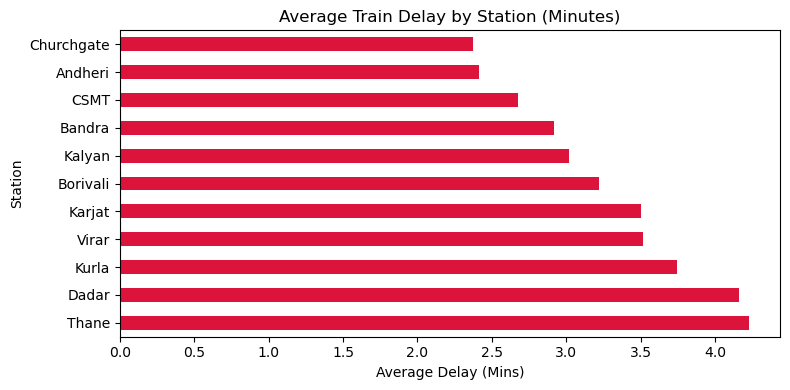

In [26]:
import matplotlib.pyplot as plt

# 1. Calculate average delay by station
station_delays = (
    df.groupby("Station")["Delay_Minutes"]
    .mean()
    .sort_values(ascending=False)
)

# 2. Plot horizontal bar chart
plt.figure(figsize=(8, 4))
station_delays.plot(kind="barh", color="crimson")

# 3. Add labels and title
plt.title("Average Train Delay by Station (Minutes)")
plt.xlabel("Average Delay (Mins)")
plt.ylabel("Station")
plt.tight_layout()
plt.show()